# 电费账单分析
AB.xlsx包含了某小区A、B两栋楼2016年-2025年的电费账单数据，每年一个工作表，包含了每个月的应交金额和实收金额。
每个工作表的结构如下：
第一行为表头，包含了房号、上年余额、1月应交、1月已交、2月应交、2月已交……12月应交、12月已交等列。
从第二行开始，每行对应一个房号的电费数据。
请完成如下任务：
1. 读取AB.xlsx中各个工作表的数据，并生成一个DataFrame对象，包含所有数据。
2. 从DataFrame中提取出所有房号的电费数据，包括应交金额和实收金额。
3. 计算每个房号累计的应交金额和实收金额，然后生成一张图表，展示每个房号的累计应交金额和累计实收金额的变化趋势。
4. 打印每个房号的电费余额，保留2位小数。
5. 统计每个月的总应交金额和总实收金额，并打印结果。


In [2]:
import pandas as pd
import numpy as np
from pandas import date_range
import matplotlib.pyplot as plt

file_path = "AB.xlsx"
# engine="openpyxl",
#sheet_names = ["2016年","2017年","2018年","2019年","2020年","2021年","2022年"]
sheet_names = ["2016年","2017年","2018年","2019年","2020年","2021年","2022年","2023年","2024年","2025年"]
df = pd.read_excel(file_path, sheet_name=sheet_names, header=0, index_col=0, na_values=['', 'NA', 'NULL'])
sheet_names = pd.ExcelFile("AB.xlsx").sheet_names

print(sheet_names)
# 获取所有列名
# columns = df.columns
# print(columns)

outer_merge = pd.DataFrame()

def read_multiple_sheets(file_path, sheets=None):
    """
    读取Excel文件中的多个工作表

    参数:
        file_path (str): Excel文件路径
        sheets: 要读取的工作表，可以是名称、索引或列表，默认为None（读取所有工作表）

    返回:
        dict: 键为工作表名称，值为对应的DataFrame
    """
    # 读取指定的工作表，返回字典
    excel_data = pd.read_excel(file_path, sheet_name=sheets)

    # 如果只读取了一个工作表，会返回DataFrame而不是字典，这里统一转为字典
    if not isinstance(excel_data, dict):
        # 获取该工作表的名称
        sheet_names = pd.ExcelFile(file_path).sheet_names
        if sheets is None:
            sheet_name = sheet_names[0]
        elif isinstance(sheets, int):
            sheet_name = sheet_names[sheets]
        else:
            sheet_name = sheets

        excel_data = {sheet_name: excel_data}

    return excel_data

#'上年余额',
column_names = ['上年余额','1月应交', '1月已交', '2月应交', '2月已交', '3月应交', '3月已交', '4月应交',
       '4月已交', '5月应交', '5月已交', '6月应交', '6月已交', '7月应交', '7月已交', '8月应交', '8月已交',
       '9月应交', '9月已交', '10月应交', '10月已交', '11月应交', '11月已交', '12月应交', '12月已交']

# 房号索引
index = ['A1801','A1802','A1803','A1804','A1701','A1702','A1703','A1704','A1601','A1602','A1603','A1604','A1501','A1502','A1503','A1504','A1401','A1402','A1403','A1404','A1301','A1302','A1303','A1304','A1201','A1202','A1203','A1204','A1101','A1102','A1103','A1104','A1001','A1002','A1003','A1004','A901','A902','A903','A904','A801','A802','A803','A804','A701','A702','A703','A704','A601','A602','A603','A604','A501','A502','A503','A504','A401','A402','A403','A404','A301','A302','A303','A304','李春园','广电','B1801','B1802','B1803','B1804','B1701','B1702','B1703','B1704','B1601','B1602','B1603','B1604','B1501','B1502','B1503','B1504','B1401','B1402','B1403','B1404','B1301','B1302','B1303','B1304','B1201','B1202','B1203','B1204','B1101','B1102','B1103','B1104','B1001','B1002','B1003','B1004','B901','B902','B903','B904','B801','B802','B803','B804','B701','B702','B703','B704','B601','B602','B603','B604','B501','B502','B503','B504','B401','B402','B403','B404','B302','B303','B304']
print("AB栋房号数量:", len(index))
all_sheets = read_multiple_sheets(file_path)

merge_df = pd.DataFrame({},index=index)
merge_payable = pd.DataFrame(index=index)
merge_received = pd.DataFrame(index=index)

B402_Payable = np.array([])
B402_Received = np.array([])
print(f"读取了 {len(all_sheets)} 个工作表:")
for sheet_name, df in all_sheets.items():
    if sheet_name == "Sheet1":
        break
    df1 = df.set_index('房号')
    #df1.columns = column_names
    #merge_df.index = df1.index
    print(f"\n工作表: {sheet_name}")
    print(f"列名: {df1.columns}")
    merge_df = pd.concat([merge_df,df1.iloc[:,1:]],axis=1,join='outer')
    merge_payable = pd.concat([merge_payable,df1.iloc[:,1::2]],axis=1,join='outer')
    merge_received = pd.concat([merge_received,df1.iloc[:,2::2]],axis=1,join='outer')
    #merge_df.columns = sheet_names
    #print(df1.values[:,1::2])
    #print(df1.values[:, 2::2])
    #print(df1.values[-6,1::2])
    B402_Payable = np.append(B402_Payable,df1.values[-6,1::2])
    B402_Received = np.append(B402_Received,df1.values[-6,2::2])
    if df1.columns.size == 25:
        payable = pd.DataFrame(df1.values[:,1::2], columns=column_names[1::2], index=df1.index)
        print(payable)
        print(payable.iloc[-6])
        received = pd.DataFrame(df1.values[:,2::2], columns=column_names[2::2], index=df1.index)
        print(received)


    #print(f"数据行数: {len(df1)}")
    #print(f"列名: {df1.columns}")
    #print(f"索引: {df1.index}")
    #print("前5行数据:")
    #print(df1.head())
    #print(df1.iloc[0])
    #merge_df.merge(df, how='outer')
    #outer_merge = pd.merge(merge_df, df, on='房号', how='outer')

# 将数据写到新的Excel文件中
merge_df.to_excel("merged_data.xlsx", index=True)
merge_payable.to_excel("payable.xlsx", index=True)
merge_received.to_excel("received.xlsx", index=True)


['2016年', '2017年', '2018年', '2019年', '2020年', '2021年', '2022年', '2023年', '2024年', '2025年']
AB栋房号数量: 129
读取了 10 个工作表:

工作表: 2016年
列名: Index(['上年余额（+）或欠交（-）', '1月应交', '1月已交', '2月应交', '2月已交', '3月应交', '3月已交', '4月应交',
       '4月已交', '5月应交', '5月已交', '6月应交', '6月已交', '7月应交', '7月已交', '8月应交', '8月已交',
       '9月应交', '9月已交', '10月应交', '10月已交', '11月应交', '11月已交', '1-12月应交', '12月已交'],
      dtype='object')
       1月应交  2月应交  3月应交  4月应交  5月应交  6月应交  7月应交  8月应交  9月应交  10月应交  11月应交  \
房号                                                                          
A1801   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN   
A1802   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN   
A1803   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN   
A1804   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN   
A1701   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN   
...     ...   ...   ...   ...   ...   ...   ...   ...   ...    ... 

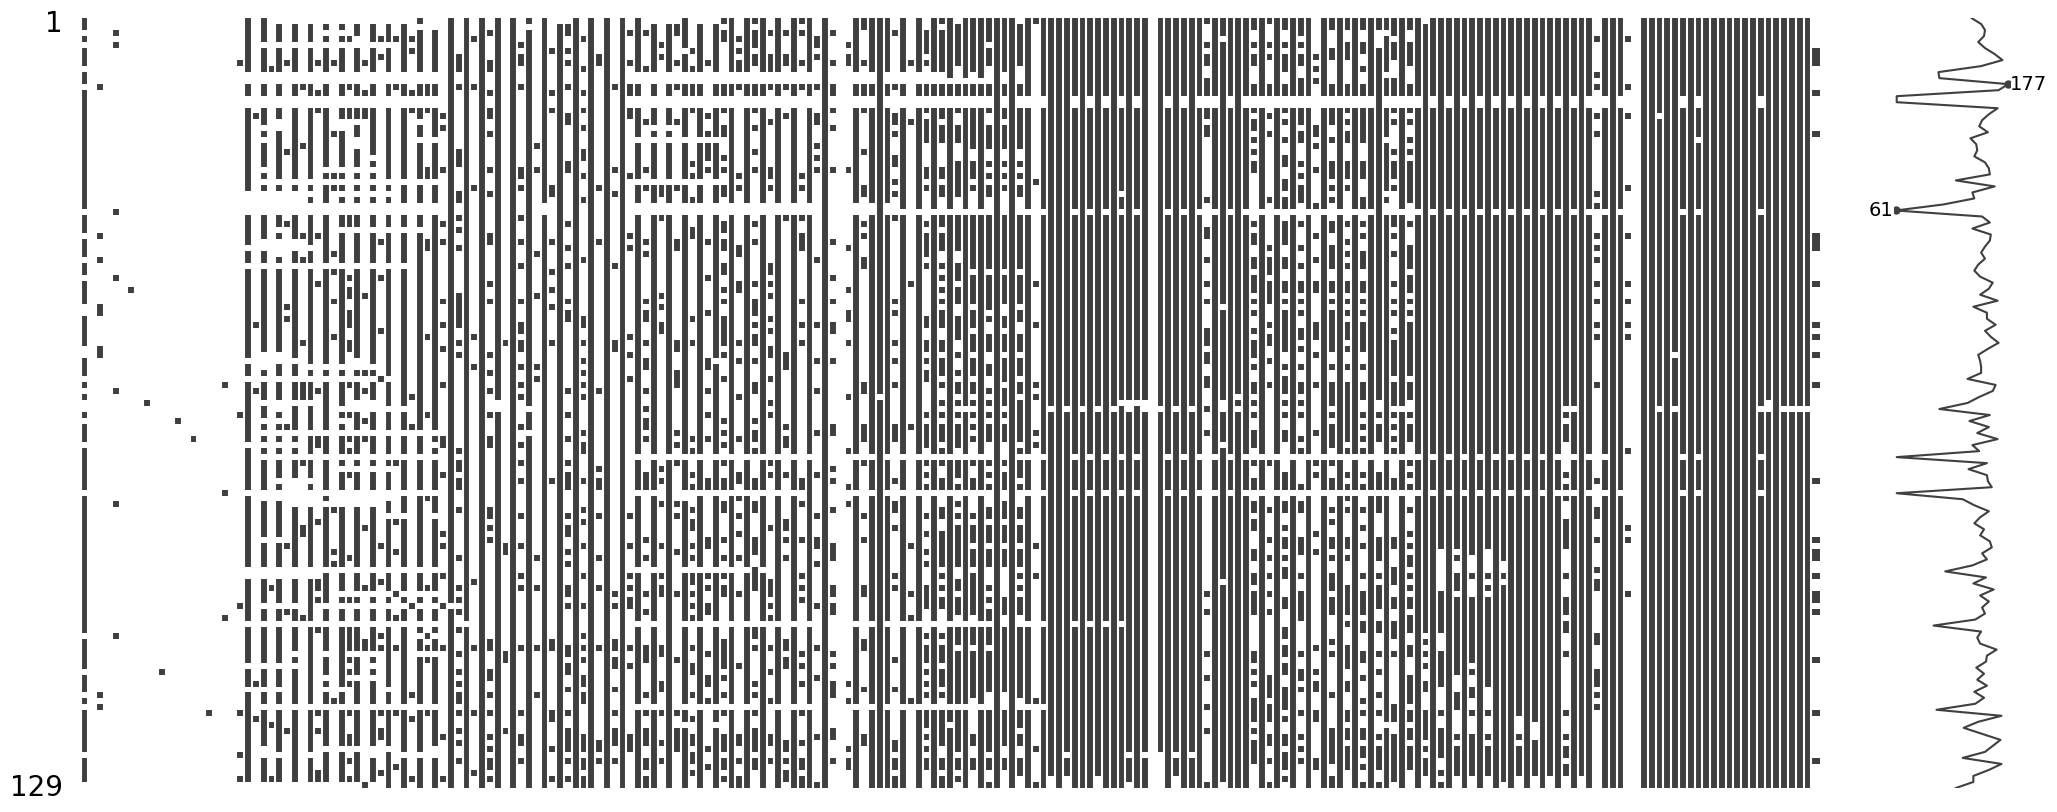

In [2]:
import missingno as msno
# 显示缺失值的矩阵图
msno.matrix(merge_df)
plt.show()

## 分析小结
1.总共有129户居民
2.从缺失的数据来看，仍有几户居民还没入住，所以没有电费账单数据。


In [1]:
#print(np.nan_to_num(merge_df.iloc[-6],nan=0.0))
#上一年余额
#indices = list(range(0,merge_df.columns.size,25))
#print("上一年余额\n",merge_df.iloc[:,indices])
#应收
indices_payable = list(range(0,merge_df.columns.size,2))
payable = merge_df.iloc[:,indices_payable]
print("应收",payable)

#实收
indices_received = list(range(1,merge_df.columns.size,2))
received = merge_df.iloc[:,indices_received]
print("实收",received)

merge_df.loc['B402']

NameError: name 'merge_df' is not defined

应交数量： 112
实收数量： 112
实收： [   0.      0.      0.      0.      0.      0.      0.      0.      0.
    0.    300.      0.      0.      0.      0.      0.      0.      0.
    0.      0.      0.      0.      0.      0.      0.      0.      0.
    0.      0.      0.      0.      0.      0.      0.      0.      0.
    0.      0.      0.   1100.      0.      0.      0.      0.      0.
    0.      0.      0.      0.      0.      0.      0.      0.      0.
    0.      0.      0.      0.      0.      0.      0.      0.     14.88
    0.     14.44   12.13   26.74    0.      0.      0.      0.      0.
    0.      0.     94.79   58.21    0.    184.68    0.      0.     37.79
   56.84   57.27   62.23   64.75  125.09    0.     10.82  221.86   67.83
   61.31   68.26   65.99   16.74   25.27   13.12    9.94    0.    120.83
    0.      0.      0.      0.    160.    160.     49.75    0.     26.06
   12.18    0.    160.      0.  ]
日期长度: 112
          Payable     Received
count  112.000000   112.000000
mean    

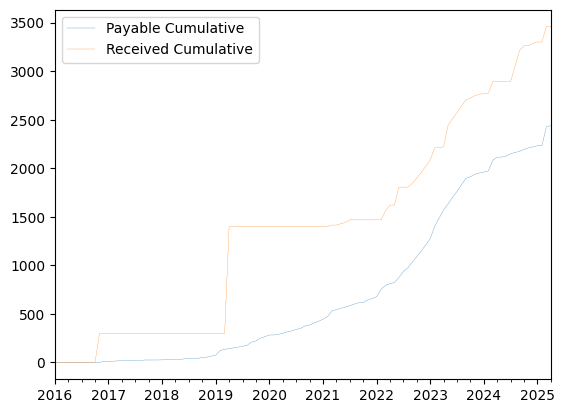

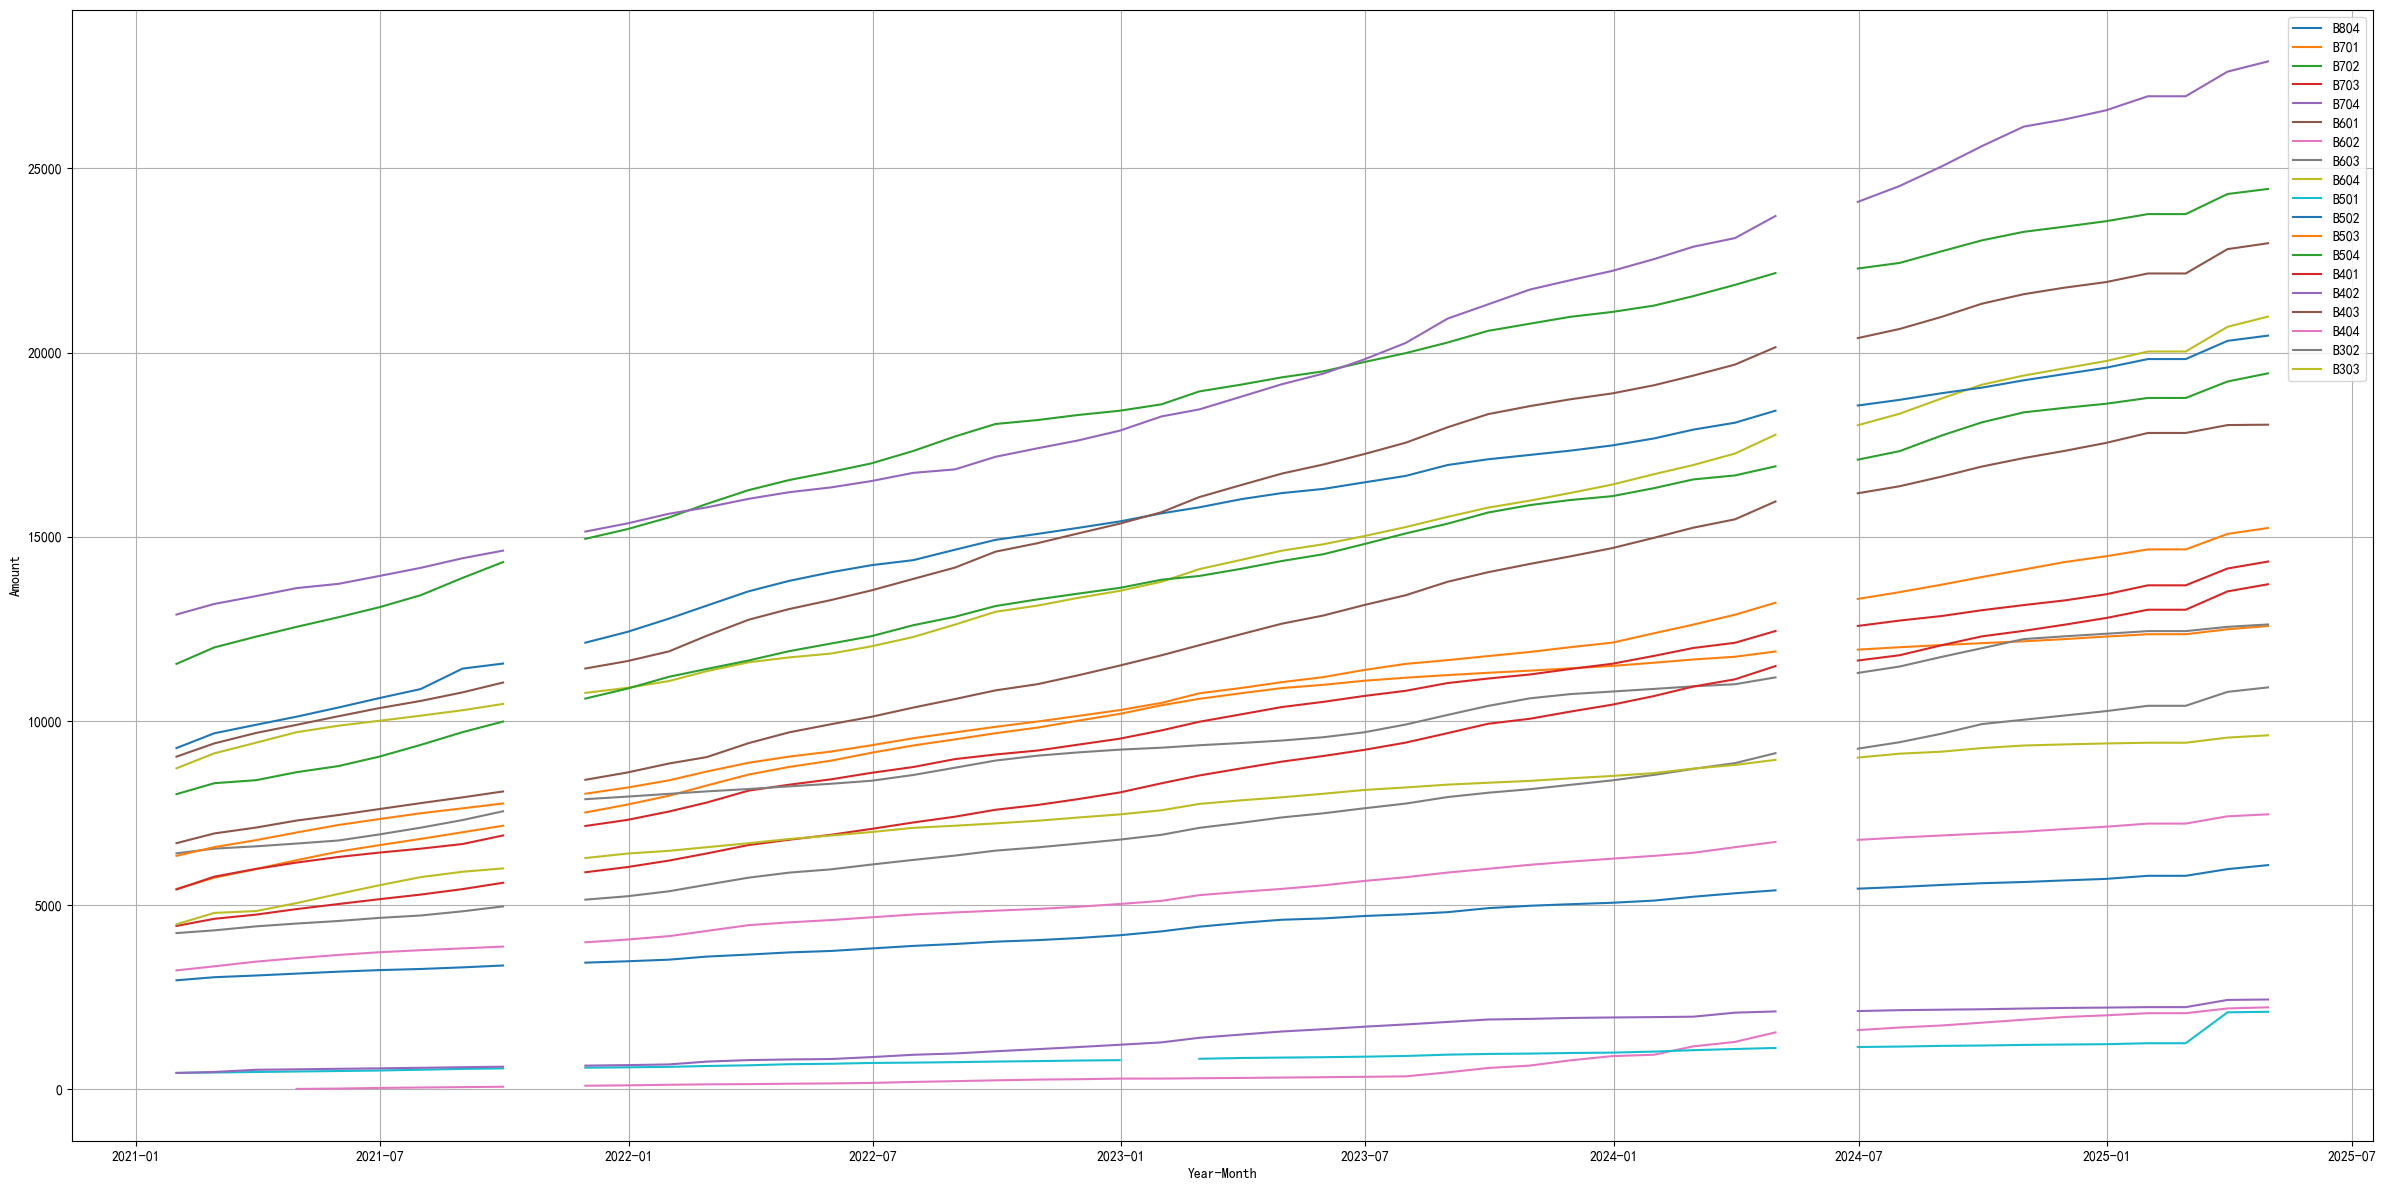

In [4]:
#### B402 应交金额和实收金额的累计和 ####
#print("B402 应交金额：",B402_Payable.describe())

B402_Payable_cumsum = np.nan_to_num(B402_Payable,nan=0.0).cumsum()
#print(B402_Payable_cumsum)
print("应交数量：",B402_Payable_cumsum.size)

B402_Received_cumsum = np.nan_to_num(B402_Received,nan=0.0).cumsum()
print("实收数量：",B402_Received_cumsum.size)
print("实收：",np.nan_to_num(B402_Received,nan=0.0))
month_num = B402_Payable_cumsum.size
date_range = date_range("2016-01-31", "2025-04-30", freq="ME")
print("日期长度:",date_range.size)


B402_Payable_Received_Month = pd.DataFrame({"Payable": np.nan_to_num(B402_Payable,nan=0.0),"Received":np.nan_to_num(B402_Received,nan=0.0)}, index=date_range)
print(B402_Payable_Received_Month.describe())


B402_Payable_Received = pd.DataFrame({"Payable Cumulative": B402_Payable_cumsum,"Received Cumulative":B402_Received_cumsum}, index=date_range)

print(B402_Payable_Received.describe())
B402_Payable_Received.plot(lw=0.2)
# B402_Payable_cumsum
# B402_Received_cumsum
plt.rcParams["font.family"] = ["SimHei"]
plt.figure(figsize=(24, 12))
#merge_payable.index = date_range
#merge_received.index = date_range

#merge_payable.boxplot()

import seaborn as sns
#payable.columns = column_names[1:12]
print(payable.describe())
# sns.heatmap(payable.iloc[:,12:24],
#             annot=True,
#             cmap="YlGnBu",
#             linewidths=.5,
#             fmt=".1f",
#             cbar_kws={"label": "数值强度"})  # 颜色条标签


# 按索引遍历
for index, row in merge_payable[-20:-1].cumsum(axis=1).iterrows():
    #print(index,row.values)
    plt.plot(date_range[60:], row[60:].values, label=index)
    # scatter = plt.scatter(date_range, row.values,
    #                     s=1, alpha=0.5, edgecolors='none')

    # 添加颜色条
    #plt.colorbar(scatter, label=index)
# plt.plot(date_range, B402_Payable_cumsum,'b.', label ='累计应收')
# plt.plot(date_range, B402_Received_cumsum,'r.', label ='累计实收')
plt.legend(loc=0)
plt.grid(True)
plt.xlabel('Year-Month')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [5]:
# 应交（上一个月的电费）
# A = df[columns[1::2]]
# A.index = df.index
# 实收
# B = df[columns[2::2]]
# B.index = df.index

# 1-12月应交
# print(A.sum(axis=1))
# 1-12月已交
# print(B.sum(axis=1))

# 上一年余额
# C = df[columns[0]]
# print(C)

# 本年余额
# print((C + B.sum(axis=1) - A.sum(axis=1)).round(2))

# 按月统计
# 应交
# print(A.sum(axis=0))
# 实收
# print(B.sum(axis=0))

# row = A.iloc[[12]]
# print(row)

# row = A.loc["B402"]
# print(A.loc["B402"].values)
#
# print(A.loc["B402"].values)
#
# a = np.array(B.loc["B402"].values)


def safe_convert_to_float(arr):
    """
    将数组元素转换为浮点数，无法转换的元素设为0

    参数:
        arr: numpy数组或可迭代对象
    返回:
        转换后的浮点数数组
    """
    # 确保输入是numpy数组
    arr = np.asarray(arr)

    # 创建相同形状的浮点数数组，初始化为0
    float_arr = np.zeros_like(arr, dtype=float)

    # 遍历每个元素进行转换
    for i in np.ndindex(arr.shape):
        try:
            # 尝试转换为浮点数
            float_arr[i] = float(arr[i])
        except (ValueError, TypeError):
            # 转换失败则保持0（已初始化）
            pass

    return float_arr


# converted = safe_convert_to_float(a)
#
# print(converted)
# print(converted.sum())
#
# range = date_range("2023-01-31", "2023-12-31", freq="ME")
# B402 = pd.DataFrame({"应交": A.loc["B402"].values, "实收": B.loc["B402"].values}, index=range)
# print(B402)

# df_outer = pd.merge(A.loc["B402"], B.loc["B402"], how='outer')
# print(df.iloc[[-6]])
# print(df.iloc[[-6]])

# df = pd.DataFrame(row,B.loc["B402"])
# df_concat = pd.concat([row, B.loc["B402"]], axis=1)  # axis=1表示按列合并
#
# print(df_concat.columns)
# print(df_concat)

# print((C + B.sum(axis=1) - A.sum(axis=1))["B402"].round(2))


## 分析结论
1.
